In [2]:
import pandas as pd

df = pd.read_csv('student_performance.csv')

df.head()

,Student_ID,Age,Gender,Study_Hours,Attendance(%),Test_Score,Grade
0,S0524,21,Female,2.7,74.0,37.0,F
1,S0603,19,Male,1.5,93.1,26.0,F
2,S0527,20,Female,6.8,97.2,88.0,A
3,S0032,18,Female,6.2,93.5,55.0,C
4,S0617,21,Male,7.4,99.2,77.0,B


## Task 1: Data Quality Issues

In [3]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicates:")
print(df.duplicated().sum())

print("\nDataset Information:")
df.info()

Missing Values:
Student_ID        0
Age               0
Gender            0
Study_Hours      31
Attendance(%)    30
Test_Score        0
Grade             9
dtype: int64

Duplicates:
20

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Student_ID     1020 non-null   object 
 1   Age            1020 non-null   int64  
 2   Gender         1020 non-null   object 
 3   Study_Hours    989 non-null    float64
 4   Attendance(%)  990 non-null    float64
 5   Test_Score     1020 non-null   float64
 6   Grade          1011 non-null   object 
dtypes: float64(3), int64(1), object(3)
memory usage: 55.9+ KB


The dataset contains several data quality issues. There are 31 missing values in Study_Hours, 30 missing values in Attendance(%), and 9 missing values in Grade. In addition, the dataset contains 20 duplicate records. These issues need to be handled before applying machine learning preprocessing techniques.

## Task 2: Missing Value Handling

In [4]:
df['Study_Hours'] = df['Study_Hours'].fillna(df['Study_Hours'].median())

df['Attendance(%)'] = df['Attendance(%)'].fillna(df['Attendance(%)'].median())

df['Grade'] = df['Grade'].fillna(df['Grade'].mode()[0])

print(df.isnull().sum())

Student_ID       0
Age              0
Gender           0
Study_Hours      0
Attendance(%)    0
Test_Score       0
Grade            0
dtype: int64


Missing values in Study_Hours and Attendance(%) were replaced using the median because it is less affected by outliers. Missing values in Grade were replaced using the mode because Grade is a categorical feature.

## Task 3: Outlier Detection and Handling Using IQR

In [5]:
numerical_cols = ['Age', 'Study_Hours', 'Attendance(%)', 'Test_Score']

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Dataset Shape After Removing Outliers:")
print(df.shape)

Dataset Shape After Removing Outliers:
(994, 7)


Outliers were detected and removed using the Interquartile Range (IQR) method. After removing outliers from the numerical features, the dataset size was reduced from 1020 rows to 994 rows. This process helps improve data quality and reduces the impact of extreme values on analysis and machine learning models.

## Task 4: Feature Normalization

In [6]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

numerical_cols = ['Age', 'Study_Hours', 'Attendance(%)', 'Test_Score']

minmax_scaler = MinMaxScaler()

df_minmax = df.copy()

df_minmax[numerical_cols] = minmax_scaler.fit_transform(
    df_minmax[numerical_cols]
)

print("Min-Max Scaling")
print(df_minmax[numerical_cols].head())

zscore_scaler = StandardScaler()

df_zscore = df.copy()

df_zscore[numerical_cols] = zscore_scaler.fit_transform(
    df_zscore[numerical_cols]
)

print("\nZ-Score Scaling")
print(df_zscore[numerical_cols].head())

Min-Max Scaling
        Age  Study_Hours  Attendance(%)  Test_Score
0  0.500000     0.272727       0.292220        0.37
1  0.166667     0.151515       0.654649        0.26
2  0.333333     0.686869       0.732448        0.88
3  0.000000     0.626263       0.662239        0.55
4  0.500000     0.747475       0.770398        0.77

Z-Score Scaling
        Age  Study_Hours  Attendance(%)  Test_Score
0  0.008016    -1.247736      -1.143716   -0.619098
1 -0.988016    -1.897251       0.877066   -1.149311
2 -0.490000     0.971441       1.310846    1.839159
3 -1.486032     0.646684       0.919386    0.248522
4  0.008016     1.296199       1.522447    1.308947


Numerical features were normalized using two different techniques: Min-Max Scaling and Z-Score Standardization. Min-Max Scaling transformed the values into a range between 0 and 1, while Z-Score Standardization centered the data around the mean with a standard deviation of 1. These techniques help improve the performance of machine learning algorithms.

## Task 5: Principal Component Analysis (PCA)

Explained Variance Ratio:
[0.46829902 0.25086838 0.24887932 0.03195329]

Cumulative Explained Variance:
[0.46829902 0.71916739 0.96804671 1.        ]


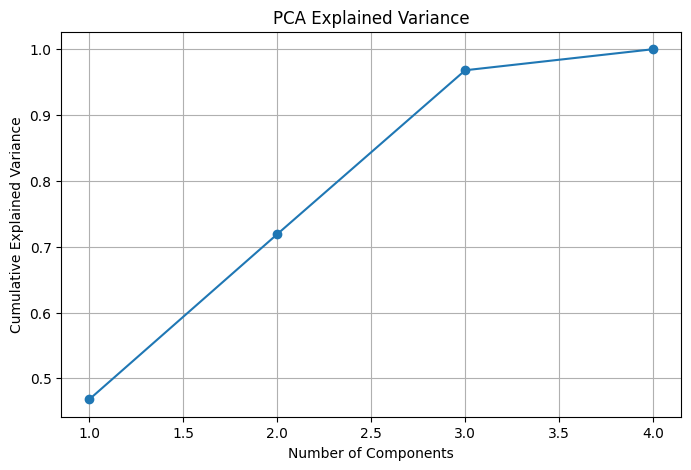

In [7]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

X = df_zscore[numerical_cols]

pca = PCA()

pca.fit(X)

explained_variance = pca.explained_variance_ratio_

print("Explained Variance Ratio:")
print(explained_variance)

print("\nCumulative Explained Variance:")
print(np.cumsum(explained_variance))

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(explained_variance)+1),
    np.cumsum(explained_variance),
    marker='o'
)

plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')

plt.grid(True)

plt.show()

Principal Component Analysis (PCA) was applied to reduce dimensionality and analyze the variance explained by each component. The first principal component explained approximately 46.83% of the variance, while the first three principal components together explained about 96.8% of the total variance. This indicates that most of the information in the dataset can be represented using only three principal components.

# Conclusion

The dataset was successfully preprocessed through data quality assessment, missing value handling, outlier removal, feature normalization, and dimensionality reduction using PCA. These preprocessing steps improved data quality and prepared the dataset for future machine learning applications.